In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [4]:
X_train = pd.read_csv("X_train_preprocessed.csv")
y_train = pd.read_csv("y_train_preprocessed.csv")
X_test = pd.read_csv("X_test_preprocessed.csv")
y_test = pd.read_csv("y_test_preprocessed.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (10618, 33)
X_test: (6000, 33)


In [3]:
from google.colab import files
uploaded = files.upload()

Saving X_test_preprocessed.csv to X_test_preprocessed.csv
Saving X_train_preprocessed.csv to X_train_preprocessed.csv
Saving y_test_preprocessed.csv to y_test_preprocessed.csv
Saving y_train_preprocessed.csv to y_train_preprocessed.csv


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC:", auc_lr)

Logistic Regression ROC-AUC: 0.7093182774394939


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", auc_rf)

Random Forest ROC-AUC: 0.7619141112881952


In [8]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4673
           1       0.45      0.63      0.52      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.74      0.76      6000

Confusion Matrix:

[[3638 1035]
 [ 496  831]]


In [9]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(10))

      feature  importance
2       PAY_0    0.097127
0   LIMIT_BAL    0.062115
8   BILL_AMT1    0.059883
1         AGE    0.058817
14   PAY_AMT1    0.052562
9   BILL_AMT2    0.051892
10  BILL_AMT3    0.049458
15   PAY_AMT2    0.049235
12  BILL_AMT5    0.048740
11  BILL_AMT4    0.047295


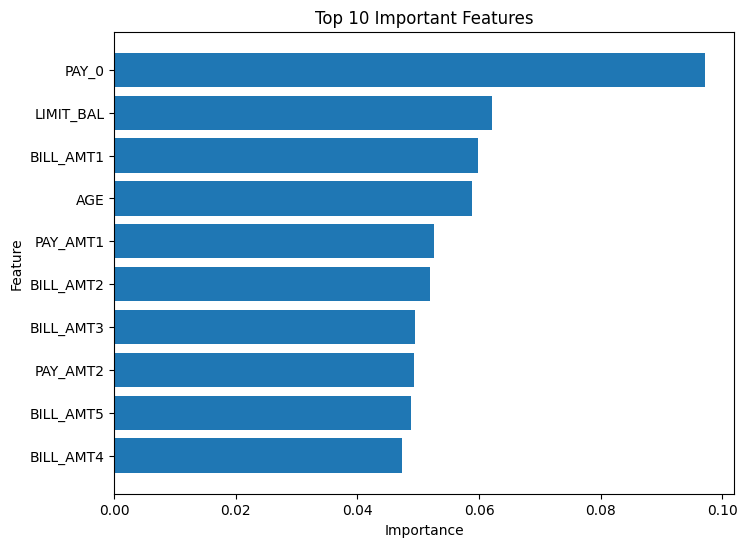

In [10]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

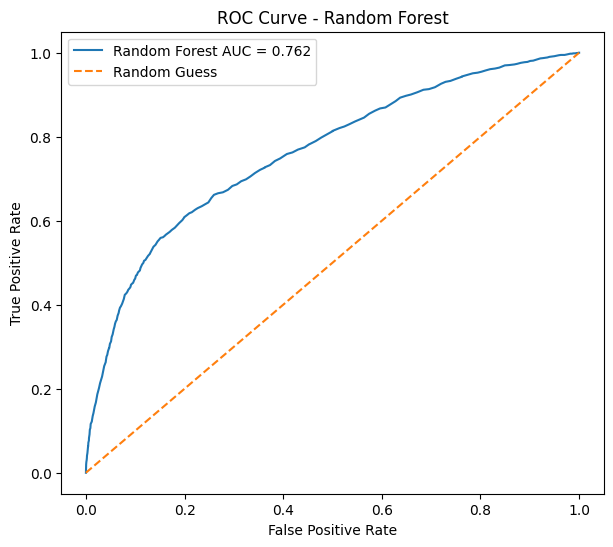

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {auc_rf:.3f}")
plt.plot([0,1], [0,1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

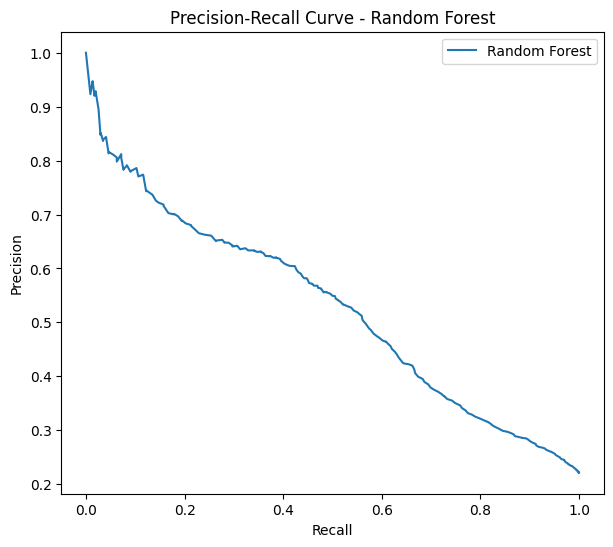

In [12]:
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5]

for t in thresholds:
    y_pred_threshold = (y_prob_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print("Threshold:", t)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-Score:", round(f1, 4))
    print("-" * 30)

Threshold: 0.3
Precision: 0.2847
Recall: 0.893
F1-Score: 0.4318
------------------------------
Threshold: 0.4
Precision: 0.3459
Recall: 0.7589
F1-Score: 0.4752
------------------------------
Threshold: 0.5
Precision: 0.4412
Recall: 0.63
F1-Score: 0.5189
------------------------------


In [ ]:
from google.colab import files
uploaded = files.upload()

In [14]:
import pandas as pd

In [15]:
X_train = pd.read_csv("X_train_preprocessed.csv")
y_train = pd.read_csv("y_train_preprocessed.csv")
X_test  = pd.read_csv("X_test_preprocessed.csv")
y_test  = pd.read_csv("y_test_preprocessed.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
import shap

X_shap = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

In [45]:
# =====================
# 1. IMPORTLAR
# =====================
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# =====================
# 2. DATA LOAD
# =====================
X_train = pd.read_csv("/content/X_train_preprocessed.csv")
y_train = pd.read_csv("/content/y_train_preprocessed.csv")
X_test  = pd.read_csv("/content/X_test_preprocessed.csv")
y_test  = pd.read_csv("/content/y_test_preprocessed.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("Data loaded:", X_train.shape, X_test.shape)

# =====================
# 3. MODEL
# =====================
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# =====================
# 4. PREDICT
# =====================
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("AUC:", auc_rf)

# =====================
# 5. FEATURE IMPORTANCE (GARANTİ)
# =====================
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(10))

# =====================
# 6. SHAP (SAFE VERSION)
# =====================
X_shap = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values[1], X_shap)

Data loaded: (10618, 33) (6000, 33)
AUC: 0.7603995342094939
      feature  importance
2       PAY_0    0.104295
0   LIMIT_BAL    0.061752
8   BILL_AMT1    0.059183
1         AGE    0.058534
14   PAY_AMT1    0.052956
9   BILL_AMT2    0.051787
15   PAY_AMT2    0.049692
10  BILL_AMT3    0.049508
12  BILL_AMT5    0.048188
11  BILL_AMT4    0.046968


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [21]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(200, 33, 2)


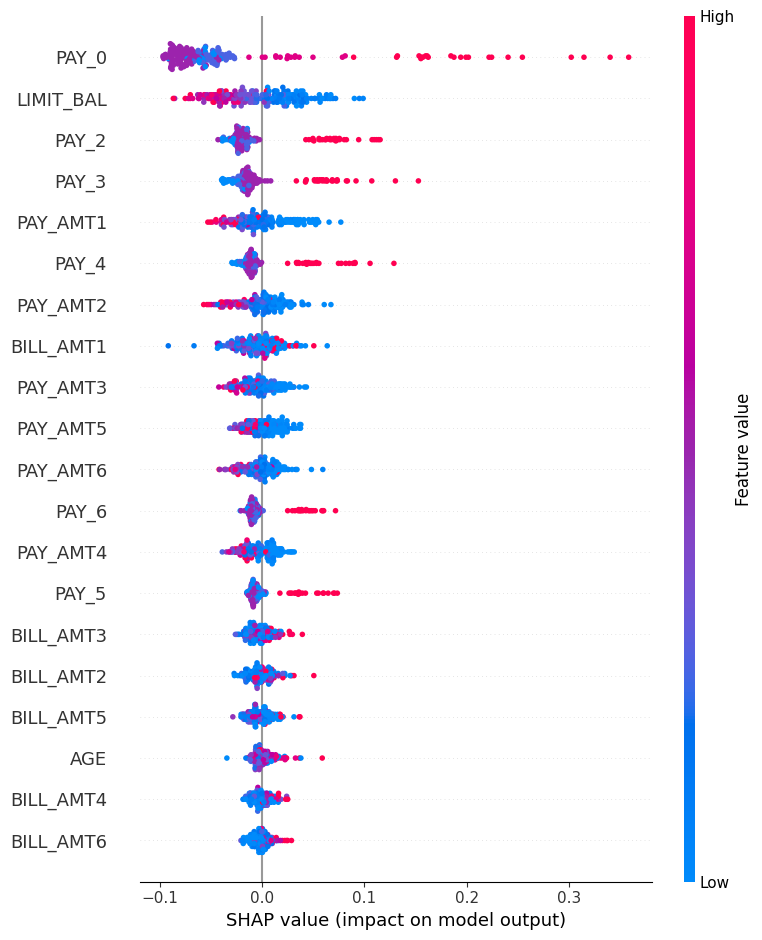

In [22]:
shap_values_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_class1, X_shap)

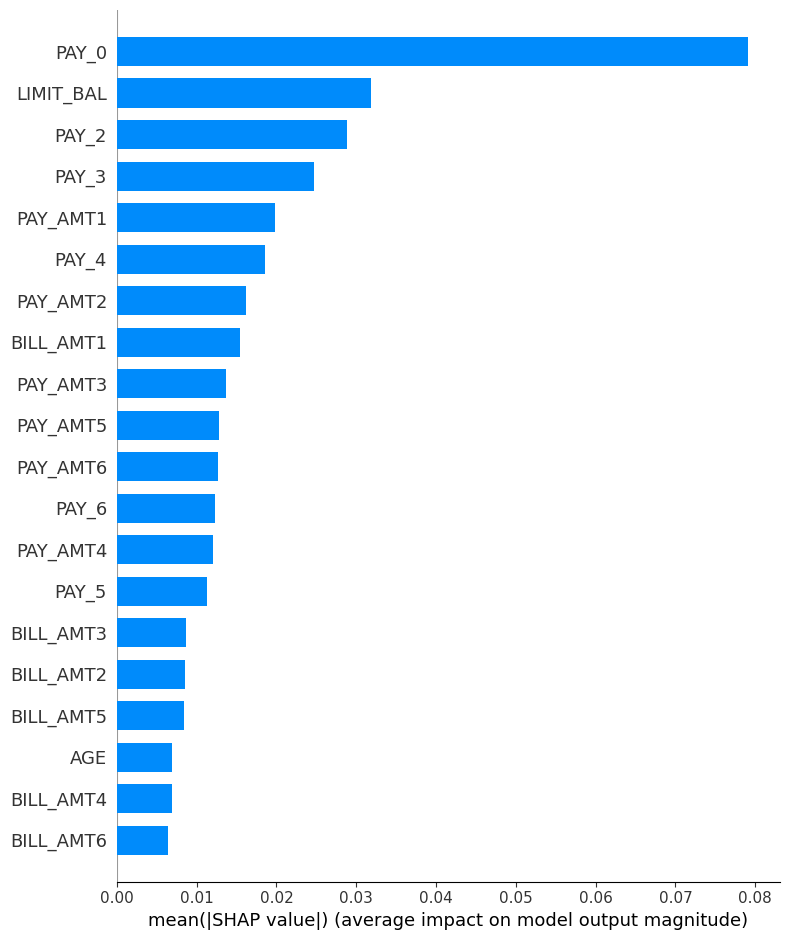

In [23]:
shap.summary_plot(shap_values_class1, X_shap, plot_type="bar")

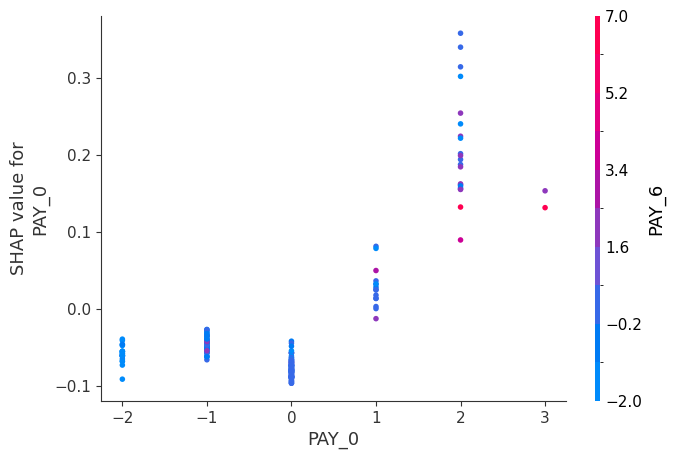

In [24]:
shap.dependence_plot("PAY_0", shap_values_class1, X_shap)

In [25]:
import numpy as np

print(np.array(shap_values).shape)

(200, 33, 2)


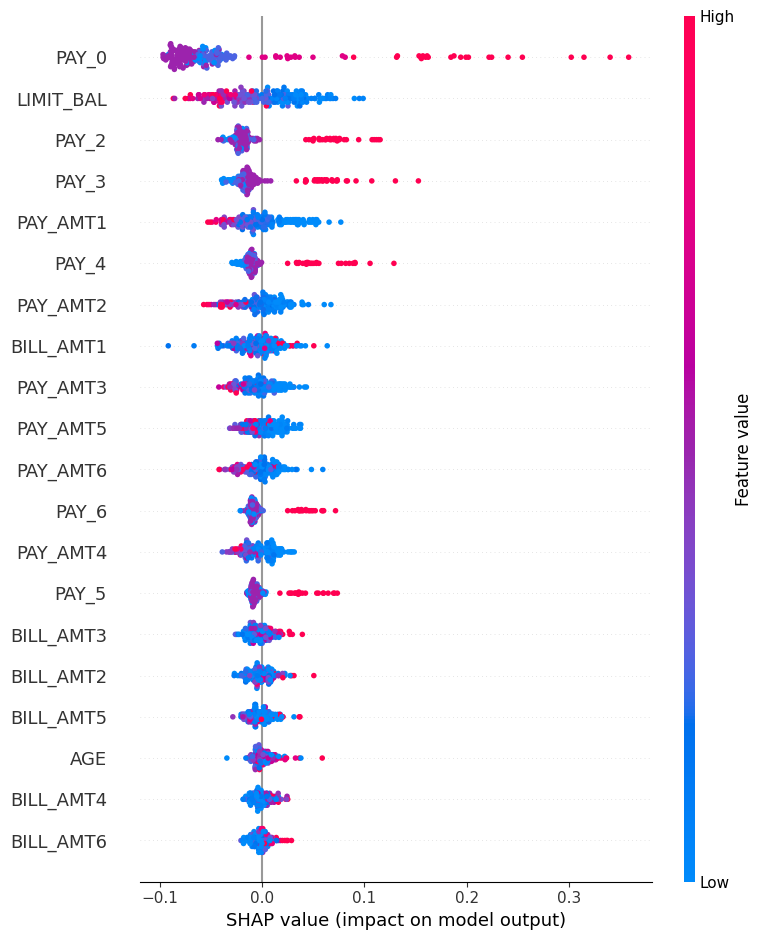

In [26]:
shap_values_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_class1, X_shap)

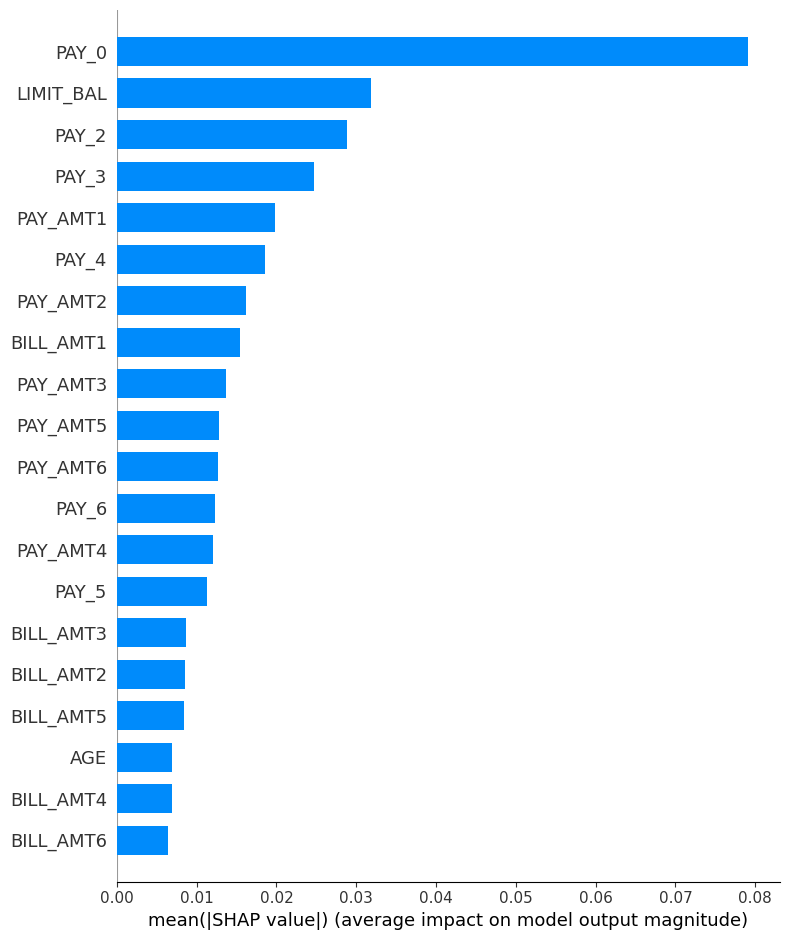

In [27]:
shap.summary_plot(shap_values_class1, X_shap, plot_type="bar")

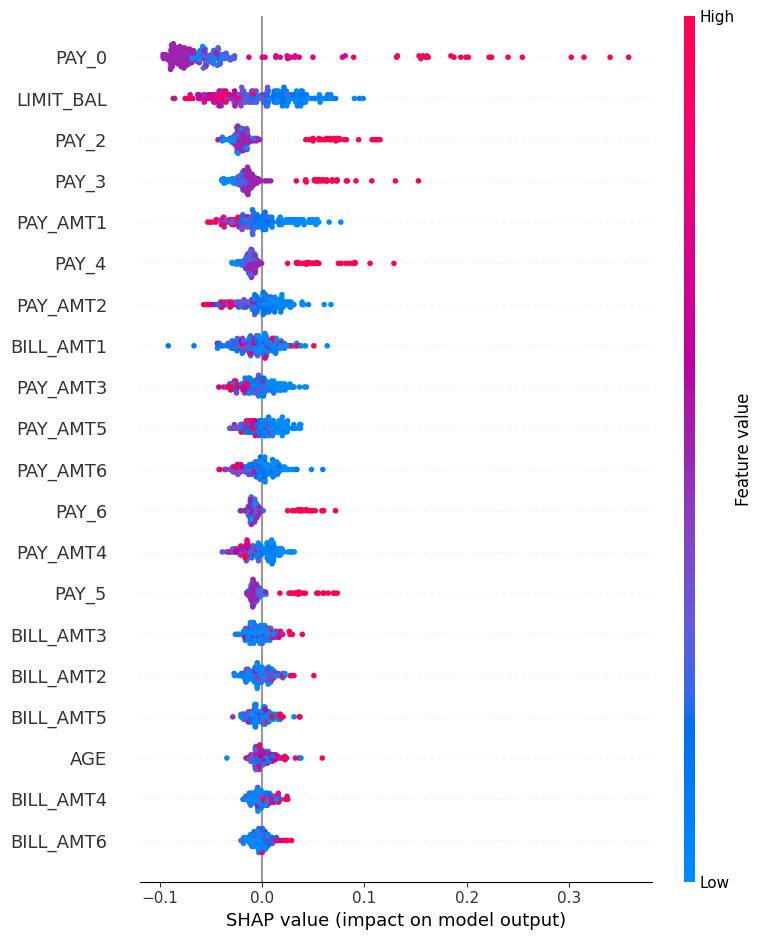

In [28]:
shap.summary_plot(shap_values[:, :, 1], X_shap)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model hazır")

Model hazır


In [30]:
import joblib

joblib.dump(rf_model, "credit_risk_model.pkl")
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

print("Model ve kolonlar kaydedildi.")
print(X_train.columns.tolist())

Model ve kolonlar kaydedildi.
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_1', 'SEX_2', 'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_0', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


In [31]:
for col in X_train.columns:
    print(col)

LIMIT_BAL
AGE
PAY_0
PAY_2
PAY_3
PAY_4
PAY_5
PAY_6
BILL_AMT1
BILL_AMT2
BILL_AMT3
BILL_AMT4
BILL_AMT5
BILL_AMT6
PAY_AMT1
PAY_AMT2
PAY_AMT3
PAY_AMT4
PAY_AMT5
PAY_AMT6
SEX_1
SEX_2
EDUCATION_0
EDUCATION_1
EDUCATION_2
EDUCATION_3
EDUCATION_4
EDUCATION_5
EDUCATION_6
MARRIAGE_0
MARRIAGE_1
MARRIAGE_2
MARRIAGE_3


In [ ]:
!python app.py

In [32]:
pip install flask-cors

In [33]:
%%writefile app.py
from flask import Flask, request, jsonify
from flask_cors import CORS
import pandas as pd
import joblib

app = Flask(__name__)
CORS(app)

model = joblib.load("credit_risk_model.pkl")
feature_names = joblib.load("feature_names.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()

    df = pd.DataFrame([data])
    df = df.reindex(columns=feature_names, fill_value=0)

    prediction = int(model.predict(df)[0])
    risk_probability = float(model.predict_proba(df)[0][1])

    importances = model.feature_importances_

    explanations = []
    for feature, value, importance in zip(feature_names, df.iloc[0].values, importances):
        explanations.append({
            "feature": feature,
            "value": float(value),
            "importance": float(importance)
        })

    explanations = sorted(explanations, key=lambda x: x["importance"], reverse=True)[:5]

    return jsonify({
        "prediction": prediction,
        "risk_probability": risk_probability,
        "risk_label": "Riskli" if prediction == 1 else "Risksiz",
        "top_explanations": explanations
    })

if __name__ == "__main__":
    app.run(debug=True)

Writing app.py


In [34]:
!python app.py

 * Serving Flask app 'app'
 * Debug mode: on
 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (inotify)
 * Debugger is active!
 * Debugger PIN: 135-382-661


In [35]:
!nohup python app.py > flask.log 2>&1 &

In [40]:
import requests

sample = X_test.iloc[0].to_dict()

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=sample,
    timeout=5
)

print(response.status_code)
print(response.json())

200
{'prediction': 0, 'risk_label': 'Risksiz', 'risk_probability': 0.4, 'top_explanations': [{'feature': 'PAY_0', 'importance': 0.10429539067974349, 'value': -1.0}, {'feature': 'LIMIT_BAL', 'importance': 0.0617517062307994, 'value': 50000.0}, {'feature': 'BILL_AMT1', 'importance': 0.05918290010088971, 'value': 1540.0}, {'feature': 'AGE', 'importance': 0.05853364119168539, 'value': 46.0}, {'feature': 'PAY_AMT1', 'importance': 0.05295554695829317, 'value': 26060.0}]}


In [41]:
!pip install pyngrok

In [46]:
from pyngrok import ngrok

ngrok.set_auth_token("3CoIFgj9BX5NvXIMckjzMIrkvSH_3rtJenXsE5Ns9AXtCHnWQ")

In [47]:
public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://unsent-spruce-washbowl.ngrok-free.dev" -> "http://localhost:5000"


You can check for active ngrok processes using the following shell commands:

*   `ps aux | grep ngrok`: This command lists all running processes and filters for ones containing 'ngrok'.
*   `lsof -i :4040`: ngrok's local web interface usually runs on port 4040. This command will show if any process is listening on that port.

In [44]:
!ps aux | grep ngrok
!lsof -i :4040

root        4405  0.7  0.2 1291632 34740 ?       Sl   17:17   0:00 /root/.config/ngrok/ngrok start --none --log stdout
root        4666  0.0  0.0   7372  3440 ?        S    17:18   0:00 /bin/bash -c ps aux | grep ngrok
root        4668  0.0  0.0   6480  2544 ?        S    17:18   0:00 grep ngrok
COMMAND  PID USER   FD   TYPE DEVICE SIZE/OFF NODE NAME
ngrok   4405 root    4u  IPv4 118556      0t0  TCP localhost:4040 (LISTEN)


In [ ]:
!kill 23094 23096

/bin/bash: line 1: kill: (23094) - No such process
/bin/bash: line 1: kill: (23096) - No such process
